In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')

In [3]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [4]:
print("shape of dataset is(rows and columns):", df.shape)

shape of dataset is(rows and columns): (5110, 12)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


/tmp/ipykernel_55/2501139039.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


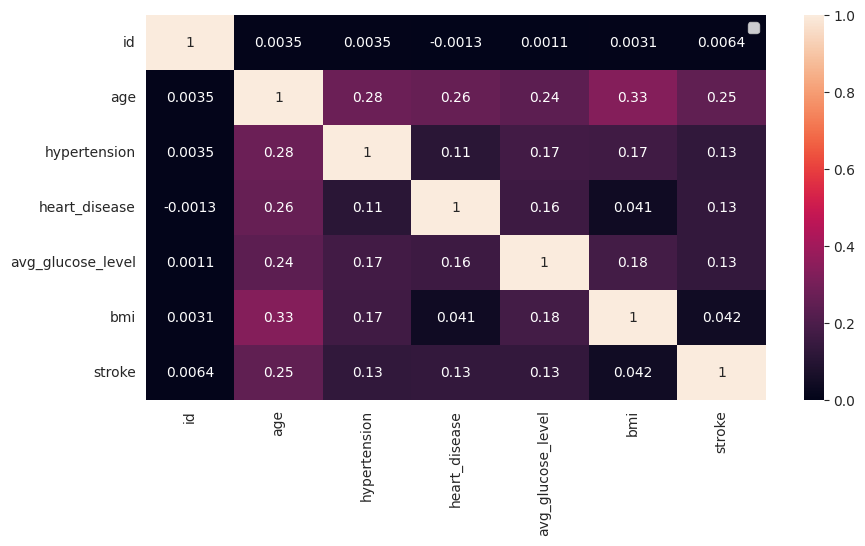

In [7]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.legend()
plt.show()

/tmp/ipykernel_55/204980714.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


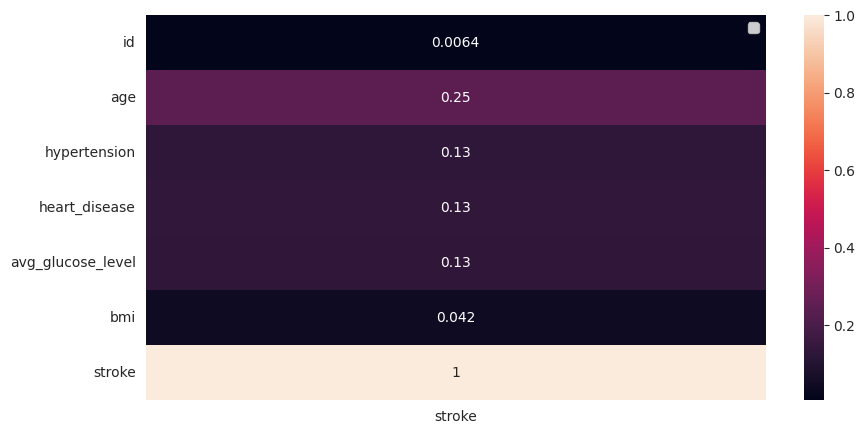

In [8]:
stroke_corr = df.corr(numeric_only=True)[['stroke']]
plt.figure(figsize=(10,5))
sns.heatmap(stroke_corr,annot=True)
plt.legend()
plt.show()

# Drop Unnecessary Columns

In [9]:
# Drop Unnecessary column
df.drop('id',axis=1,inplace =True)

In [10]:
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


# Handling Missing Values

In [11]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

# bmi

In [12]:
## Fill the missing value with median
df['bmi'].fillna(df['bmi'].median(),inplace=True)

/tmp/ipykernel_55/2248309188.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].median(),inplace=True)


In [13]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [14]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

# Stroke

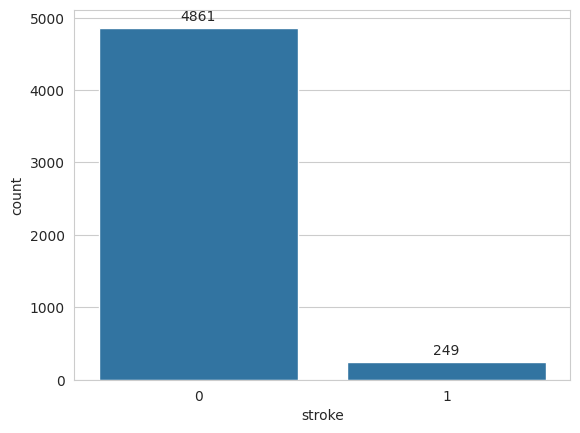

In [27]:
ax = sns.countplot(x='stroke',data=df)
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

# age

<Axes: xlabel='age'>

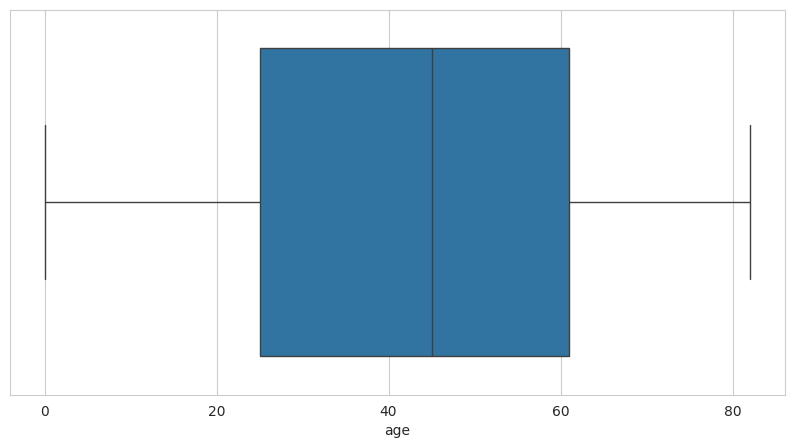

In [26]:
plt.figure(figsize=(10,5))
sns.boxplot(x='age', data=df)

# gender

In [18]:
sorted(df['gender'].unique())

['Female', 'Male', 'Other']

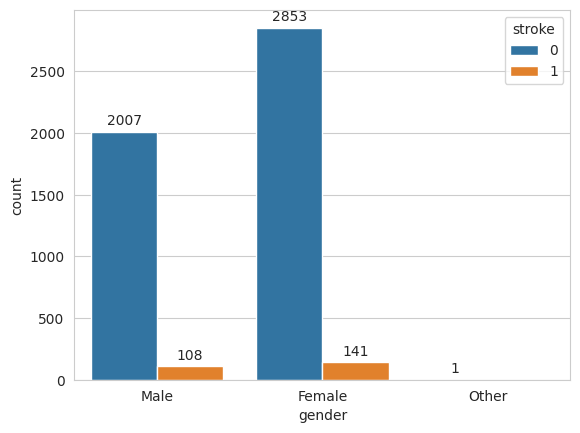

In [25]:
ax = sns.countplot(x='gender',hue='stroke',data=df)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

# 

# ever_married

In [20]:
sorted(df['ever_married'].unique())

['No', 'Yes']

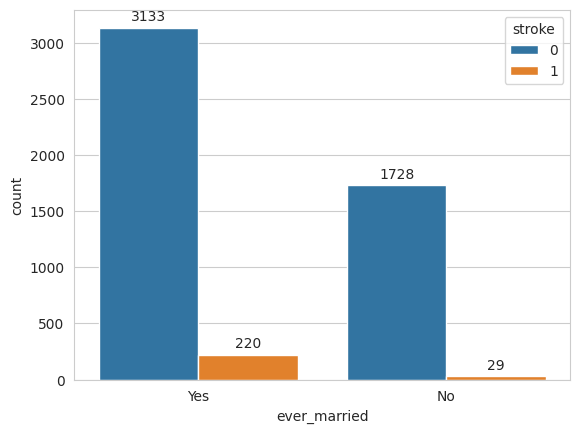

In [22]:
ax= sns.countplot(x='ever_married',hue='stroke',data=df)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

# work_type 

In [29]:
sorted(df['work_type'].unique())

['Govt_job', 'Never_worked', 'Private', 'Self-employed', 'children']

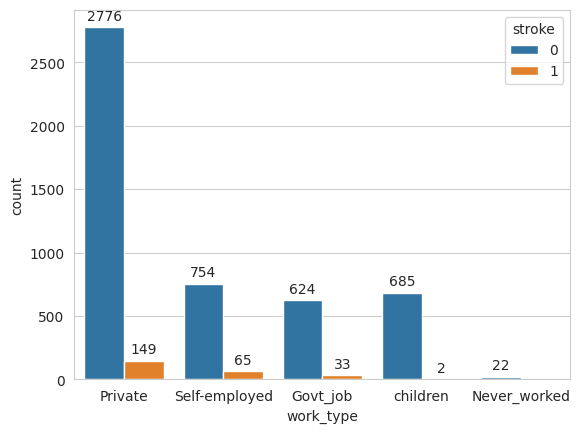

In [28]:
ax = sns.countplot(x='work_type',hue='stroke',data=df)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

# Residence_type

In [30]:
sorted(df['Residence_type'].unique())

['Rural', 'Urban']

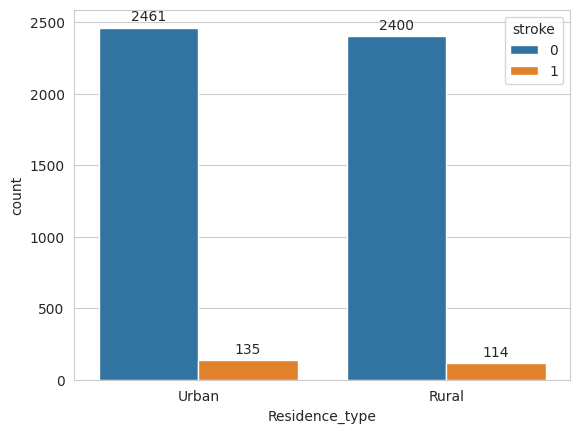

In [31]:
ax = sns.countplot(x='Residence_type',hue='stroke',data=df)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

# smoking_status

In [32]:
sorted(df['smoking_status'].unique())

['Unknown', 'formerly smoked', 'never smoked', 'smokes']

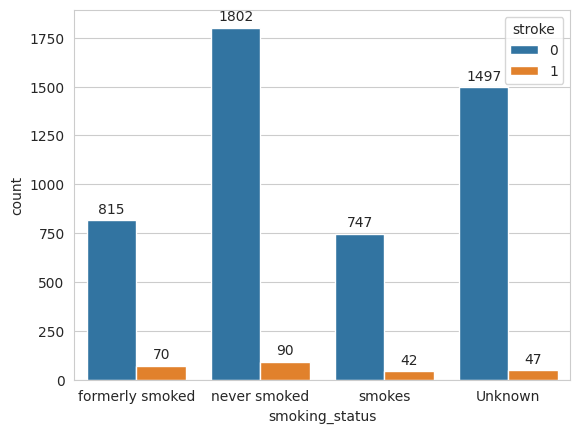

In [33]:
ax = sns.countplot(x='smoking_status',hue='stroke',data=df)
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.show()

# Label Encoding 

In [34]:
## Using Label encoder for categorical columns
from sklearn.preprocessing import LabelEncoder

lb =  LabelEncoder()
df = df.apply(lb.fit_transform)
 


In [35]:
df.head(10)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,88,0,1,1,2,1,3850,239,1,1
1,0,82,0,0,1,3,0,3588,154,2,1
2,1,101,0,1,1,2,0,2483,198,2,1
3,0,70,0,0,1,2,1,3385,217,3,1
4,0,100,1,0,1,3,0,3394,113,2,1
5,1,102,0,0,1,2,1,3448,163,1,1
6,1,95,1,1,1,2,0,588,147,2,1
7,0,90,0,0,0,2,1,1951,101,2,1
8,0,80,0,0,1,2,0,912,154,0,1
9,0,99,0,0,1,2,1,126,115,0,1


# correlation Between stroke & other columns

/tmp/ipykernel_55/204980714.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


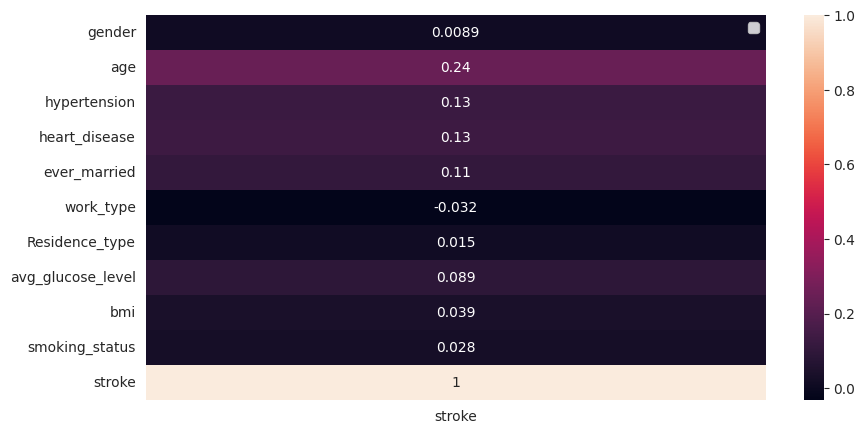

In [36]:
stroke_corr = df.corr(numeric_only=True)[['stroke']]
plt.figure(figsize=(10,5))
sns.heatmap(stroke_corr,annot=True)
plt.legend()
plt.show()

In [37]:
df.to_csv('/kaggle/working/clean_dataset.csv',index=False)